# Task 2 — NDS Event Matching (upgraded)

**Pipeline (4 ranking methods):**

1. **TF-IDF** — sparse word + bigram cosine similarity (sklearn)
2. **SBERT** — `all-MiniLM-L6-v2` dense cosine similarity (GPU)
3. **Hybrid** — `0.5 * normalize(TF-IDF) + 0.5 * normalize(SBERT)`
4. **Reranked** — `0.7 * Hybrid + 0.3 * entity_overlap` (boosts candidates sharing bit sizes / equipment / problem keywords with the query)

**Pre-processing improvements over v1:**
- **Bidirectional abbreviation expansion** — `POOH` ↔ `pull out of hole`, `BHA` ↔ `bottom hole assembly`, `RIH`, `BOP`, `MWD`, plus 50+ more drilling abbrevs. Both forms appear in normalized text so TF-IDF and SBERT see consistent vocabulary regardless of which form the writer used.
- **Query cleanup** — fixes Excel's `26""""` quote-escape mess, known typos (`ccumulation`, `ecountered`), and duplicate-word artifacts (`to to 0.16`).

**Scoping:**
- F-10, F-11, F-12 → strict matching against same-well operations.
- F-13 → cross-well fallback (no PDFs exist for F-13).

**Outputs:**
- `outputs/task2_matches.csv` — long-form, 4 events × 4 methods × top-5 ranks = 80 rows
- `outputs/task2_benchmark.csv` — wide-form, top-1 per method side-by-side per event

**Prerequisite:** Notebook 01 has been run (DuckDB is populated).

## 0. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import pandas as pd
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 220)

## 1. Load NDS events & preview the normalization

See exactly what the cleanup + abbreviation expansion does to each event.

In [2]:
from src.task2_matching.nds_events import load_nds_events
from src.task2_matching.text_normalization import clean_query, normalize_for_query

events = load_nds_events()
events

INFO     Loaded 4 NDS events.

INFO     Wells in NDS events: ['15_9_F_10', '15_9_F_11', '15_9_F_12', '15_9_F_13']

,event_id,well_raw,well_family,event_text,has_pdf_corpus
0,1,15/9-F-10,15_9_F_10,inclination angle was higher than expected. Reduced inclination to to 0.16 deg,True
1,2,15/9-F-11,15_9_F_11,tight hole event was ecountered while drilling interval at 958 m,True
2,3,15/9-F-12,15_9_F_12,"Excessive clay amount ccumulation is observed in BHA while POOH 26"""" BHA",True
3,4,15/9-F-13,15_9_F_13,"while RIH with 20"" casing there was a differential stuck. The mud was replaced to seawater and 300 m3 of seawater was pumped, Set down w...",False


In [3]:
# Show before/after normalization for each event
for _, e in events.iterrows():
    print(f"--- Event {e['event_id']} ({e['well_raw']}) ---")
    print(f"  RAW:        {e['event_text']}")
    print(f"  CLEANED:    {clean_query(e['event_text'])}")
    print(f"  NORMALIZED: {normalize_for_query(e['event_text'])}")
    print()

--- Event 1 (15/9-F-10) ---
  RAW:        inclination angle was higher than expected. Reduced inclination to to 0.16 deg
  CLEANED:    inclination angle was higher than expected. Reduced inclination to 0.16 deg
  NORMALIZED: inclination angle was higher than expected. Reduced inclination to 0.16 deg

--- Event 2 (15/9-F-11) ---
  RAW:        tight hole event was ecountered while drilling interval at 958 m
  CLEANED:    tight hole event was encountered while drilling interval at 958 m
  NORMALIZED: tight hole event was encountered while drilling interval at 958 m

--- Event 3 (15/9-F-12) ---
  RAW:        Excessive clay amount ccumulation is observed in BHA while POOH 26"" BHA
  CLEANED:    Excessive clay amount accumulation is observed in BHA while POOH 26" BHA
  NORMALIZED: Excessive clay amount accumulation is observed in BHA (bottom hole assembly) while POOH (pull out of hole) 26" BHA (bottom hole assembly)

--- Event 4 (15/9-F-13) ---
  RAW:        while RIH with 20" casing there w

## 2. Build (or load cached) indexes

**Important:** the corpus is normalized BEFORE TF-IDF fitting and SBERT encoding. If you ran an earlier (un-normalized) version of this notebook, **delete `data/processed/*` first** to force a rebuild — otherwise you'll be querying old indexes.

In [4]:
# Force rebuild=True the first time you run with the new normalization,
# then set it back to False.
from src.task2_matching.indexes import get_or_build_indexes

tfidf, sbert, corpus = get_or_build_indexes(force_rebuild=True)

print(f"\nCorpus:       {len(corpus):,} operation rows")
print(f"TF-IDF:       {tfidf.matrix.shape[0]:,} docs × {tfidf.matrix.shape[1]:,} features")
print(f"SBERT:        {sbert.embeddings.shape[0]:,} docs × {sbert.embeddings.shape[1]} dim")
print(f"SBERT model:  {sbert.model_name}")

INFO     Loaded corpus: 11199 operation rows

INFO     Building TF-IDF (no fresh cache)

INFO     Built TF-IDF: 11199 docs × 31464 features in 3.7s

INFO     Saved TF-IDF index → C:\Users\user\Downloads\eilink_ra_ds\eilink_ra_ds\data\processed\tfidf_index.pkl

INFO     Building SBERT embeddings (no fresh cache)

...

INFO     HTTP Request: GET https://huggingface.co/api/models/sentence-transformers/all-MiniLM-L6-v2 "HTTP/1.1 200  
         OK"

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

INFO     Built SBERT: 11199 docs × 384 dim in 80.4s

INFO     Saved SBERT index → C:\Users\user\Downloads\eilink_ra_ds\eilink_ra_ds\data\processed\sbert_embeddings.npy,
         C:\Users\user\Downloads\eilink_ra_ds\eilink_ra_ds\data\processed\sbert_op_ids.npy


Corpus:       11,199 operation rows
TF-IDF:       11,199 docs × 31,464 features
SBERT:        11,199 docs × 384 dim
SBERT model:  sentence-transformers/all-MiniLM-L6-v2


## 3. Sanity check: extract entities from one NDS event and one operation

Verify the entity extractor sees the things we'd expect (bit sizes, equipment, problem keywords).

In [5]:
from src.task2_matching.entities import extract_entities

# F-12 NDS event
event3 = events[events["well_family"] == "15_9_F_12"].iloc[0]
ent_event = extract_entities(normalize_for_query(event3["event_text"]))

print(f"Event:  {event3['event_text']}\n")
print(f"  bit_sizes:   {ent_event.bit_sizes}")
print(f"  problem_kw:  {ent_event.problem_kw}")
print(f"  equipment:   {ent_event.equipment}")
print(f"  depths_md:   {ent_event.depths_md}")

Event:  Excessive clay amount ccumulation is observed in BHA while POOH 26"" BHA

  bit_sizes:   {'26"'}
  problem_kw:  {'accumulation', 'clay'}
  equipment:   {'POOH', 'BHA'}
  depths_md:   set()


## 4. Run the full pipeline (all 4 methods)

This pre-extracts entities for every operation row (~10s), then for each event runs TF-IDF, SBERT, the hybrid blend, and the reranker. Writes both CSVs.

In [6]:
from src.task2_matching.run_matching import run_matching

summary = run_matching(force_rebuild_indexes=False, top_k=5)
summary

INFO     ============================================================

INFO     Task 2 — NDS event matching

INFO     ============================================================

INFO     Loaded 4 NDS events.

INFO     Wells in NDS events: ['15_9_F_10', '15_9_F_11', '15_9_F_12', '15_9_F_13']

...

INFO     Produced 80 match rows for 4 events.

INFO     Wrote 80 match rows → C:\Users\user\Downloads\eilink_ra_ds\eilink_ra_ds\outputs\task2_matches.csv

INFO     Wrote benchmark (4 events) → C:\Users\user\Downloads\eilink_ra_ds\eilink_ra_ds\outputs\task2_benchmark.csv

INFO     Summary: {'n_events': 4, 'n_match_rows': 80, 'n_strict_events': 3, 'n_fallback_events': 1, 'n_methods': 4,
         'top_k': 5, 'matches_csv':                                                                                
         'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task2_matches.csv', 'benchmark_csv':    
         'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task2_benchmark.csv',                   
         'all_methods_agree': 0, 'n_benchmark_rows': 4}

{'n_events': 4,
 'n_match_rows': 80,
 'n_strict_events': 3,
 'n_fallback_events': 1,
 'n_methods': 4,
 'top_k': 5,
 'matches_csv': 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task2_matches.csv',
 'benchmark_csv': 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task2_benchmark.csv',
 'all_methods_agree': 0,
 'n_benchmark_rows': 4}

## 5. Inspect: top-1 per method per event

This is the headline result. Look at where the 4 methods agree (validation) and where they disagree (insight).

In [7]:
from src.common.config import TASK2_MATCHES_CSV, TASK2_BENCHMARK_CSV

matches = pd.read_csv(TASK2_MATCHES_CSV)
benchmark = pd.read_csv(TASK2_BENCHMARK_CSV)

print(f"Total match rows: {len(matches)}")
print(f"Methods:          {sorted(matches['match_method'].unique())}")
print(f"Events:           {matches['event_id'].nunique()}")

Total match rows: 80
Methods:          ['hybrid', 'reranked', 'sbert', 'tfidf']
Events:           4


In [8]:
# Per-event method comparison — easiest view of the upgrade's value
benchmark[[
    "event_id", "nds_well", "match_type",
    "tfidf_pdf", "sbert_pdf", "hybrid_pdf", "reranked_pdf",
    "all_methods_agree",
]]

,event_id,nds_well,match_type,tfidf_pdf,sbert_pdf,hybrid_pdf,reranked_pdf,all_methods_agree
0,1,15/9-F-10,strict_same_well,15_9_F_10_2009_04_12.pdf,15_9_F_10_2009_04_08.pdf,15_9_F_10_2009_04_12.pdf,15_9_F_10_2009_04_12.pdf,False
1,2,15/9-F-11,strict_same_well,15_9_F_11_T2_2013_04_02.pdf,15_9_F_11_T2_2013_04_19.pdf,15_9_F_11_T2_2013_04_02.pdf,15_9_F_11_T2_2013_04_02.pdf,False
2,3,15/9-F-12,strict_same_well,15_9_F_12_2010_09_24.pdf,15_9_F_12_2007_07_23.pdf,15_9_F_12_2007_08_26.pdf,15_9_F_12_2007_07_12.pdf,False
3,4,15/9-F-13,cross_well_fallback,15_9_F_10_2009_04_18.pdf,15_9_19_ST2_1993_04_05.pdf,15_9_F_10_2009_04_18.pdf,15_9_F_10_2009_04_18.pdf,False


## 6. Drill-down: F-12 case study

This is the case where v1 (raw TF-IDF / SBERT) failed to surface the best match. The reranker should now catch it.

In [9]:
f12_top1 = matches[
    (matches["nds_well"].str.contains("F-12", case=False, na=False))
    & (matches["rank"] == 1)
]
for _, r in f12_top1.iterrows():
    print(f"--- {r['match_method'].upper()} ---")
    print(f"  PDF:    {Path(r['matched_pdf']).name}")
    print(f"  score:  {r['similarity_score']:.3f}  (tfidf={r['tfidf_score']:.3f}  sbert={r['sbert_score']:.3f}  entity={r['entity_overlap']:.3f})")
    print(f"  remark: {(str(r['matched_remark']) or '')[:200]}")
    print()

--- TFIDF ---
  PDF:    15_9_F_12_2010_09_24.pdf
  score:  0.358  (tfidf=0.358  sbert=0.000  entity=0.200)
  remark: POOH with BHA #2.

--- SBERT ---
  PDF:    15_9_F_12_2007_07_23.pdf
  score:  0.637  (tfidf=0.163  sbert=0.637  entity=0.100)
  remark: POOH with 17 1/2" drilling BHA from 1546 m to 1467 m MD. Tight hole took approx 30 MT overpull. -- other

--- HYBRID ---
  PDF:    15_9_F_12_2007_08_26.pdf
  score:  0.876  (tfidf=0.299  sbert=0.585  entity=0.200)
  remark: Continued POOH w/ BHA and L/O same.

--- RERANKED ---
  PDF:    15_9_F_12_2007_07_12.pdf
  score:  0.720  (tfidf=0.295  sbert=0.513  entity=0.500)
  remark: POOH w/ 26" BHA. Lubricated F/ 1002m T/ 870m. 442 lpm, 2.5 bars, 80 rpm, 8 - 20 KNm.



## 7. F-13 cross-well fallback

F-13 has no PDFs in the corpus, so we searched everything. Where did each method find evidence?

In [10]:
f13 = matches[
    (matches["nds_well"].str.contains("F-13", case=False, na=False))
    & (matches["rank"] == 1)
]
if len(f13) == 0:
    print("No F-13 matches.")
else:
    for _, r in f13.iterrows():
        print(f"--- {r['match_method'].upper()} ---")
        print(f"  PDF:    {Path(r['matched_pdf']).name}")
        print(f"  WELL:   {r['matched_well_family']}")
        print(f"  score:  {r['similarity_score']:.3f}  (tfidf={r['tfidf_score']:.3f}  sbert={r['sbert_score']:.3f}  entity={r['entity_overlap']:.3f})")
        print(f"  remark: {(str(r['matched_remark']) or '')[:200]}")
        print()

--- TFIDF ---
  PDF:    15_9_F_10_2009_04_18.pdf
  WELL:   15_9_F_10
  score:  0.230  (tfidf=0.230  sbert=0.594  entity=0.350)
  remark: Attempted to RIH with 20" casing / 18 3/4" WH - negative. Worked to free pipe with alternating up/down weights, 50 MT set down / 60 MT overpull - negative - 20" casing differential stuck. n -- fish St

--- SBERT ---
  PDF:    15_9_19_ST2_1993_04_05.pdf
  WELL:   15_9_19
  score:  0.671  (tfidf=0.132  sbert=0.671  entity=0.100)
  remark: CONT RIH WITH 4 1/2" PH-4 TEST TUBING TO 3199 M RTTS PACKER DEPTH. TOOK 20 MT WEIGHT, WORKED STRING FREE. RIH, TOOK 10 MT WEIGHT AT 3208 AND 3216 uation -- rig up M. WORKED STRING OUT, NOT ABLE TO PAS

--- HYBRID ---
  PDF:    15_9_F_10_2009_04_18.pdf
  WELL:   15_9_F_10
  score:  0.943  (tfidf=0.230  sbert=0.594  entity=0.350)
  remark: Attempted to RIH with 20" casing / 18 3/4" WH - negative. Worked to free pipe with alternating up/down weights, 50 MT set down / 60 MT overpull - negative - 20" casing differential stu

## 8. Top-5 reranked matches per event

Useful for the slide deck — shows the depth of the result, not just the top-1.

In [11]:
rer = matches[matches["match_method"] == "reranked"].sort_values(["event_id", "rank"])
for event_id, sub in rer.groupby("event_id"):
    print(f"=== Event {event_id}: {sub.iloc[0]['nds_well']} ===")
    print(f"    {sub.iloc[0]['nds_event_text']}")
    print()
    for _, r in sub.iterrows():
        print(f"  rank={r['rank']}  score={r['similarity_score']:.3f}  pdf={Path(r['matched_pdf']).name}")
        print(f"    [tfidf={r['tfidf_score']:.3f}  sbert={r['sbert_score']:.3f}  entity={r['entity_overlap']:.3f}]")
        print(f"    {(str(r['matched_remark']) or '')[:160]}")
        print()

=== Event 1: 15/9-F-10 ===
    inclination angle was higher than expected. Reduced inclination to to 0.16 deg

  rank=1  score=0.608  pdf=15_9_F_10_2009_04_12.pdf
    [tfidf=0.234  sbert=0.262  entity=0.000]
    Reamed interval 222-246 m MD in order to reduce inclination. Parameters : Flow 3500 lpm / SPP 95 bar / 140 RPM / Torque 2-4 kNm. Pumped 2 x 10 m3 hivis pills. R

  rank=2  score=0.546  pdf=15_9_F_10_2009_04_08.pdf
    [tfidf=0.131  sbert=0.355  entity=0.000]
    Drilled 36" hole from 165 m to 207 m (17 1/2" bit depth). 90-100 RPM, 5 ton WOB, 4000-4450 lpm, 3,7 kNm, ROP 5-20 m/hr. Pumped HIVIS pills as per progra m. Took

  rank=3  score=0.339  pdf=15_9_F_10_2009_04_12.pdf
    [tfidf=0.059  sbert=0.255  entity=0.000]
    Reamed interval 230-246 m MD in order to reduce inclination. Parameters : Flow 3500 lpm / SPP 97 bar / 40 RPM / Torque 2-4 kNm. drill

  rank=4  score=0.333  pdf=15_9_F_10_2009_04_12.pdf
    [tfidf=0.059  sbert=0.248  entity=0.000]
    Drilled 26" hole from 217 

## 9. Score distributions

How do the four methods' similarity scores compare?

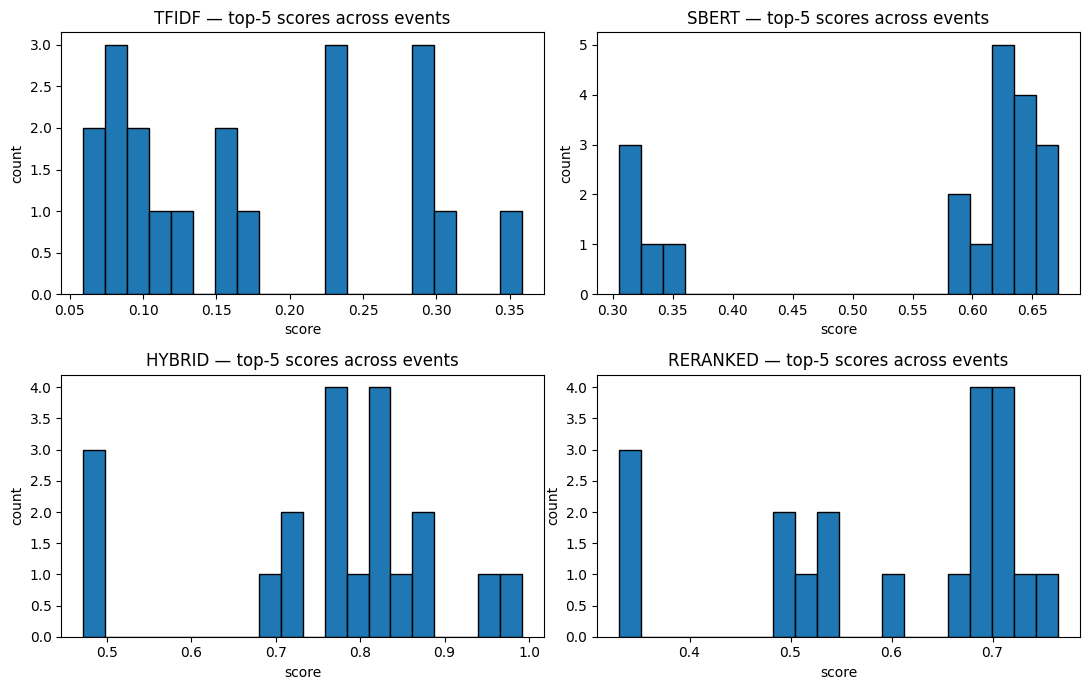

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, method in zip(axes.flat, ["tfidf", "sbert", "hybrid", "reranked"]):
    sub = matches[matches["match_method"] == method]
    ax.hist(sub["similarity_score"], bins=20, edgecolor="black")
    ax.set_title(f"{method.upper()} — top-5 scores across events")
    ax.set_xlabel("score")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## ✅ Task 2 done

**Outputs:**
- `outputs/task2_matches.csv` — full match table (all 4 methods × top-5)
- `outputs/task2_benchmark.csv` — top-1 comparison across methods

**Continue to:** `03_task3_nlp.ipynb` for NLP analysis.